In [1]:
# 05_shap_xai
#
# 목적: 학습된 LightGBM 모델(models/lightgbm_final.txt)에 SHAP을 적용해
#      (1) 전체적으로 어떤 피처가 이탈 예측에 중요한지, (2) 개별 고객 단위로 왜 이탈 위험이
#      높다고 예측했는지를 설명한다.
#
# 주의: SHAP은 "모델이 무엇을 근거로 그렇게 예측했는가"를 보여주는 것이지, 실제 이탈의
#      진짜 원인(인과관계)을 증명하는 것이 아니다. 상관관계 기반 설명으로 이해해야 한다.
#
# 입력: data/processed/model_table_final.csv, models/lightgbm_final.txt
# 출력: data/processed/shap_sample.pkl (재사용을 위한 SHAP 값 캐시, 06단계 세그멘테이션에서 사용)

In [2]:
import pickle
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]
# 50,000행으로는 TreeExplainer가 900초 타임아웃을 넘겨서 5,000행으로 축소
# (모델의 num_leaves=212, best_iteration=1202로 트리가 크고 많아 SHAP 계산 비용이 큼)
SAMPLE_SIZE = 5_000
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")
df["city"] = df["city"].astype("int64").astype("category")
df["registered_via"] = df["registered_via"].astype("int64").astype("category")
df["gender"] = df["gender"].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

test_df = df[df["split"] == "test"]
sample_df = test_df.sample(n=min(SAMPLE_SIZE, len(test_df)), random_state=RANDOM_STATE).reset_index(drop=True)
X_sample = sample_df[FEATURE_COLS]

model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
print(f"SHAP 계산 대상: test split 샘플 {len(X_sample):,}행")

SHAP 계산 대상: test split 샘플 5,000행


In [4]:
t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP 계산 소요 시간: {time.time() - t0:.1f}s")

# LightGBM 이진분류의 shap_values는 (n, features) 형태로 나오거나 [class0, class1] 리스트로 나올 수 있음
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"shap_values shape: {shap_values.shape}")

SHAP 계산 소요 시간: 89.5s
shap_values shape: (5000, 40)


C:\Users\playdata2\SKN34-2nd-2Team\myvenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


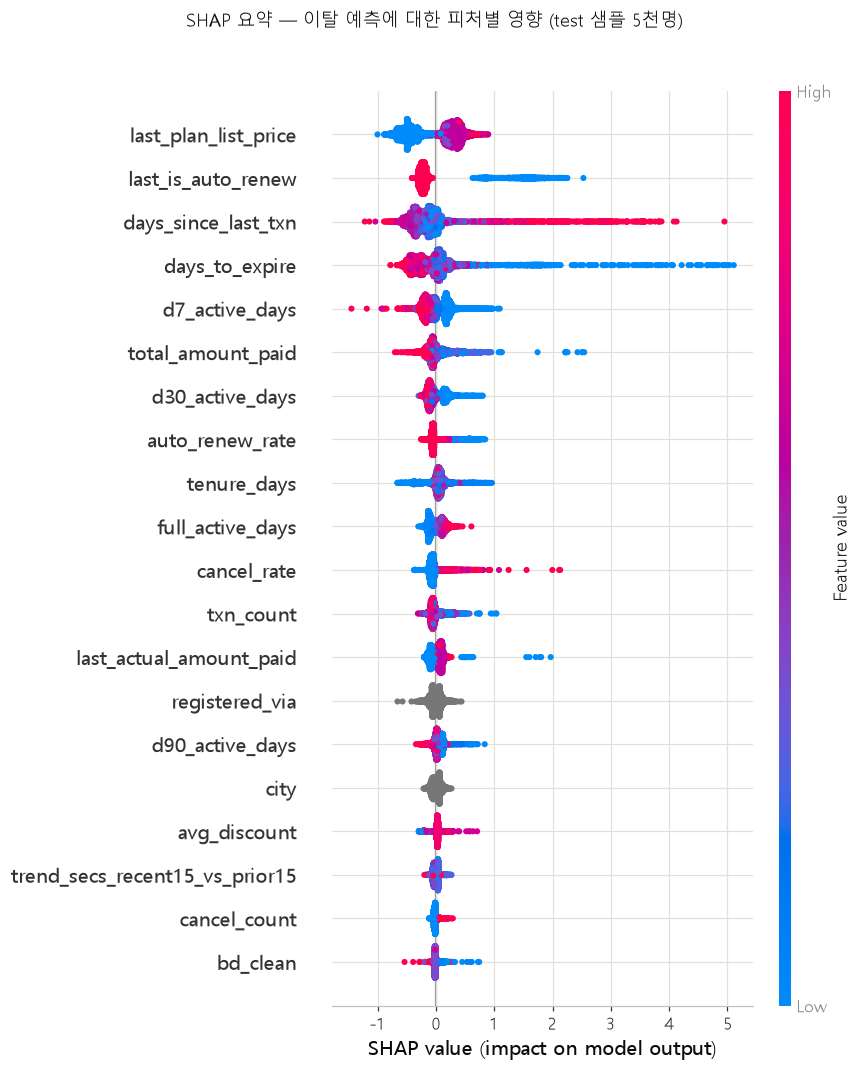

In [5]:
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
fig = plt.gcf()
fig.suptitle("SHAP 요약 — 이탈 예측에 대한 피처별 영향 (test 샘플 5천명)", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
top_features = mean_abs_shap.head(4).index.tolist()
print("SHAP 기준 상위 피처:")
print(mean_abs_shap.head(10))

SHAP 기준 상위 피처:
last_plan_list_price    0.377568
last_is_auto_renew      0.367726
days_since_last_txn     0.345206
days_to_expire          0.326790
d7_active_days          0.168456
total_amount_paid       0.139213
d30_active_days         0.119744
auto_renew_rate         0.117918
tenure_days             0.103523
full_active_days        0.100890
dtype: float64


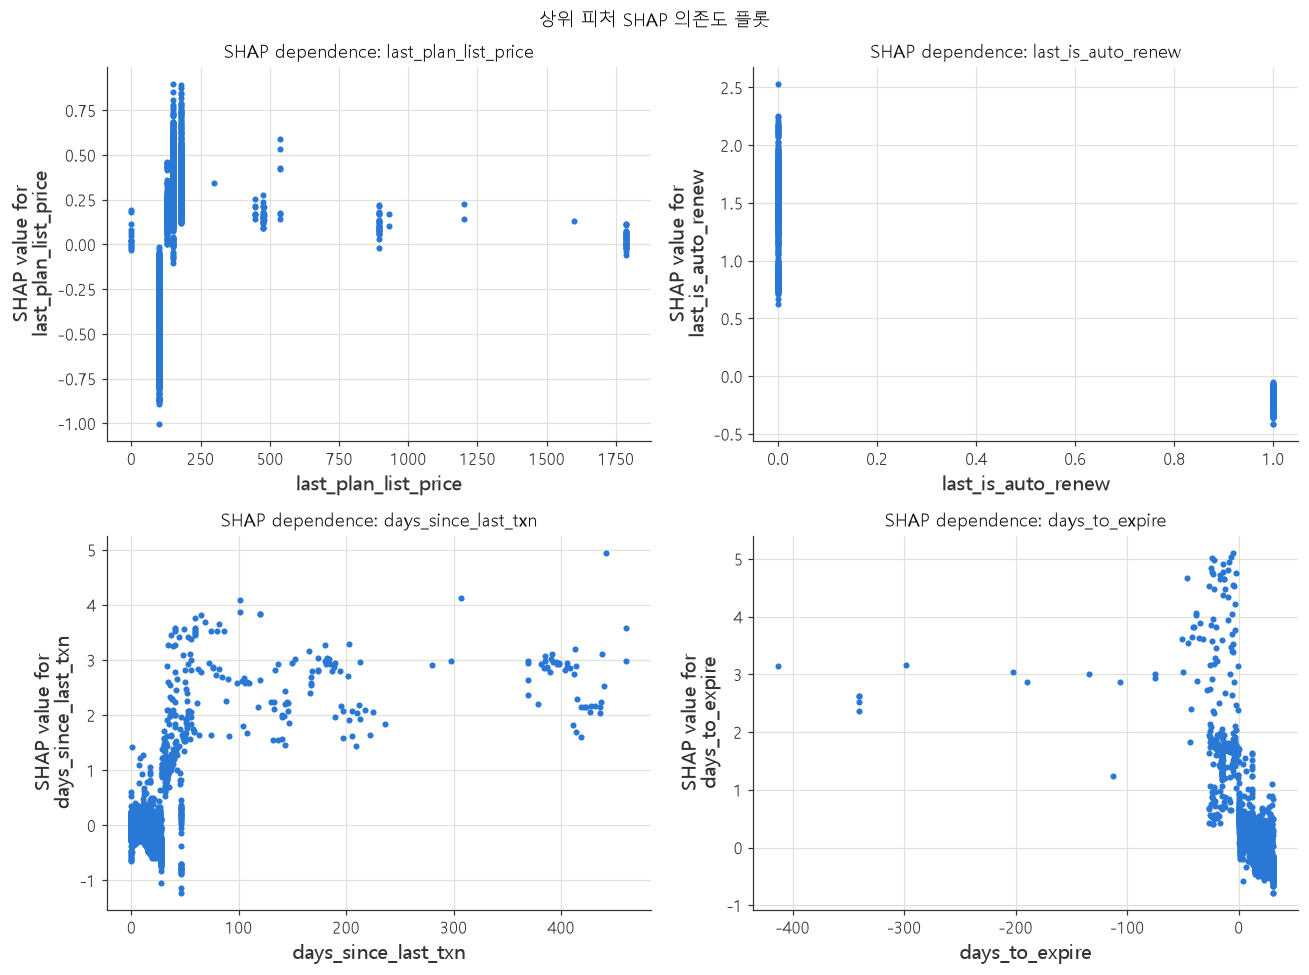

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top_features):
    shap.dependence_plot(feat, shap_values, X_sample, ax=ax, show=False, interaction_index=None, color=SERIES_1)
    ax.set_title(f"SHAP dependence: {feat}")
fig.suptitle("상위 피처 SHAP 의존도 플롯")
plt.tight_layout()
plt.show()

In [8]:
# 개별 고객 설명 예시: 샘플 중 예측 이탈확률이 가장 높은 고객 1명
pred_proba = model.predict(X_sample)
top_risk_idx = int(np.argmax(pred_proba))

print(f"예시 고객 msno: {sample_df.loc[top_risk_idx, 'msno']}")
print(f"예측 이탈확률: {pred_proba[top_risk_idx]:.4f}")

customer_shap = pd.Series(shap_values[top_risk_idx], index=FEATURE_COLS).sort_values(key=abs, ascending=False)
print("\n이 고객의 이탈확률에 가장 크게 기여한 피처 top 10 (SHAP value):")
print(customer_shap.head(10))

예시 고객 msno: 01Ic24hRxWmLtTFmHvroExb+eiZ6I91KedAoAcOCy7o=
예측 이탈확률: 0.9975

이 고객의 이탈확률에 가장 크게 기여한 피처 top 10 (SHAP value):
days_since_last_txn               2.977310
days_to_expire                    2.621181
last_is_auto_renew                0.957511
d30_active_days                   0.638248
last_actual_amount_paid           0.525300
d7_active_days                    0.412002
d90_active_days                   0.360519
cancel_rate                       0.257315
auto_renew_rate                   0.193151
trend_secs_recent15_vs_prior15    0.181098
dtype: float64


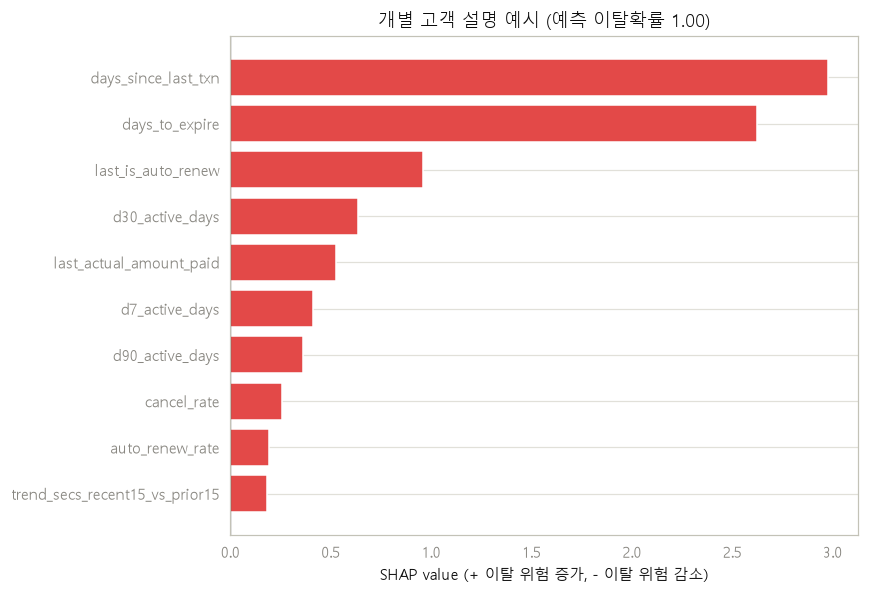

In [9]:
top10 = customer_shap.head(10).sort_values()
colors = ["#e34948" if v > 0 else "#2a78d6" for v in top10.values]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index, top10.values, color=colors)
ax.axvline(0, color="#0b0b0b", linewidth=0.8)
ax.set_xlabel("SHAP value (+ 이탈 위험 증가, - 이탈 위험 감소)")
ax.set_title(f"개별 고객 설명 예시 (예측 이탈확률 {pred_proba[top_risk_idx]:.2f})")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [10]:
with open(PROCESSED_DIR / "shap_sample.pkl", "wb") as f:
    pickle.dump({
        "msno": sample_df["msno"].values,
        "feature_cols": FEATURE_COLS,
        "X_sample": X_sample,
        "shap_values": shap_values,
        "pred_proba": pred_proba,
    }, f)
print(f"저장 완료: {PROCESSED_DIR / 'shap_sample.pkl'} (06단계 세그멘테이션에서 재사용)")

저장 완료: ..\data\processed\shap_sample.pkl (06단계 세그멘테이션에서 재사용)


In [11]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. SHAP은 "모델이 이 예측을 할 때 각 피처를 얼마나/어느 방향으로 반영했는가"를 보여주는 것이지,
#    실제 유저의 이탈 원인을 인과적으로 증명하는 것이 아니다.
# 2. test split 5천 명 샘플 기준 분석이며, 전체 모집단과 분포가 다를 수 있다.
# ------------------------------------------------------------------
print("SHAP 분석 완료 (위 주석의 해석 주의사항 참고)")

SHAP 분석 완료 (위 주석의 해석 주의사항 참고)
